In [1]:
#import all later needed modules
import pandas as pd
from sqlalchemy import create_engine
from pathlib import Path
import urllib.parse
import os
import numpy as np
import holidays
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
import optuna
import xgboost as xgb
import shap

In [2]:
# use already existent data if its available or query the database if it's not
if not os.path.exists("merged.csv"):

    # %% Define MySQL connection parameters
    db_user = "student"
    db_password = "#q6a21I&OA5k"
    host = "132.252.60.112"
    port = 3306
    dbname = "ENTSOE"


    #  %%Create MySQL engine
    engine = create_engine(
        f"mysql://{urllib.parse.quote_plus(db_user)}:{urllib.parse.quote_plus(db_password)}@{host}:{port}/{dbname}"
    )

    # %% Obtain specification table
    spec_query = "SELECT * FROM spec"
    spec = pd.read_sql_query(spec_query, engine)

    # Get an overview
    print(spec)
    spec.MapTypeCode.unique()
    spec.MapCode.unique()
    spec.Name.unique()
    spec.ProductionType.unique()
    spec.ResolutionCode.unique()
    spec.to_csv("spec.csv")

    # %% Get value by the production types, you can add more
    #  Narrow down the spec table to get the targetTimeSeriesID's
    targets = spec[
        (spec["Name"] == "Generation")
        & (spec["Type"].isin(["DayAhead", "Actual"]))
        & (spec["ProductionType"].isin(["Wind Onshore", "Wind Offshore", "Solar"]))
        & (spec["MapCode"] == "AT")  # Put desired BZN here
        & (spec["MapTypeCode"] == "BZN")
    ]


    # %% Obtain the forecasts table
    values_query = f"""
    SELECT *
    FROM vals
    WHERE TimeSeriesID IN ({", ".join(map(str, targets['TimeSeriesID']))})
    AND YEAR(`DateTime`) >= '2014'
    """
    values = pd.read_sql_query(values_query, engine)


    # %%

    # Get the actual data
    data = pd.merge(values, targets, on="TimeSeriesID")
    data = data[data["DateTime"].dt.year >= 2014]  # You can change the year here

    # Select and wrangle even further
    data = data[["DateTime", "Type", "ProductionType", "Value"]]
    data = data.sort_values(by="DateTime")
    data_generations = data.pivot_table(
        index="DateTime", columns=["Type", "ProductionType"], values="Value"
    )

    print(data_generations)
    data_generations.describe()
    data_generations.to_csv("data_generations.csv")

    # We have used the DE_LU BZN in the earlier example (data_generations). 
    # You can get DE_AT_LU or any other zone data, such as FR, PT, and so on. 
    # The DE_AT_LU zone was split into DE_LU and AT. 
    # Please take a closer look at the specs. 
    # To supplement further, you may follow the "R" codes.

    # ************************************************************************
    # %% Load data
    # *************************************************************************

    #  Narrow down the spec table to get the targetTimeSeriesID's
    targets = spec[
        (spec["Name"] == "Load")
        & (spec["Type"].isin(["DayAhead", "Actual"]))
        & (spec["MapCode"] == "AT")  # Put desired BZN here
        & (spec["MapTypeCode"] == "BZN")
    ]


    # %% Obtain the forecasts table
    values_query = f"""
    SELECT *
    FROM vals
    WHERE TimeSeriesID IN ({", ".join(map(str, targets['TimeSeriesID']))})
    AND YEAR(`DateTime`) >= '2014'
    """
    values = pd.read_sql_query(values_query, engine)

    # Get the actual data
    data = pd.merge(values, targets, on="TimeSeriesID")
    data = data[data["DateTime"].dt.year >= 2014]

    # Select and wrangle even further
    data = data[["DateTime", "Type", "Value"]]
    data = data.sort_values(by="DateTime")
    data_load = data.pivot_table(index="DateTime", columns=["Type"], values="Value")

    print(data_load)
    data_load.describe()
    data_load.to_csv("data_load.csv")

    # You can save the data to your desired directory, for further use

    # ************************************************************************
    # %% Priece data
    # *************************************************************************
    #  Narrow down the spec table to get the targetTimeSeriesID's
    targets = spec[
        (spec["Name"] == "Price")
        & (spec["Type"].isin(["DayAhead", "Actual"]))
        # & (spec["ProductionType"].isin(["Wind Onshore", "Wind Offshore", "Solar"]))
        & (spec["MapCode"] == "AT")  # Put desired price zones (BZN)here
        & (spec["MapTypeCode"] == "BZN")
    ]


    # %% Obtain the forecasts table
    values_query = f"""
    SELECT *
    FROM vals
    WHERE YEAR(`DateTime`) >= '2014'AND
    TimeSeriesID IN ({", ".join(map(str, targets['TimeSeriesID']))})"""


    values = pd.read_sql_query(values_query, engine)

    # Get the actual data
    data = pd.merge(values, targets, on="TimeSeriesID")
    data = data[data["DateTime"].dt.year >= 2014]

    # Select and wrangle even further
    data = data[["DateTime", "Type", "Value"]]
    data = data.sort_values(by="DateTime")
    data_price = data.pivot_table(index="DateTime", columns=["Type"], values="Value")

    print(data_price)
    data_price.describe()
    data_price.to_csv("data_price.csv")

    
    # Merge the dataframes
    # For data_generations (2 column levels: Type + ProductionType)
    # This flattens the MultiIndex columns by joining the two levels with an underscore
    data_generations.columns = ['_'.join(col).strip() for col in data_generations.columns.values]

    # for data_load (only typ as columnname)
    data_load.columns = [f'Load_{col}' for col in data_load.columns]

    # for data_price (only typ as columnname)
    data_price.columns = [f'Price_{col}' for col in data_price.columns]

    # Merge the dataframes on DateTime
    merged = (
        pd.merge(data_generations, data_load, on="DateTime", how="outer")
        .merge(data_price, on="DateTime", how="outer")
    )
    # print and save the data
    print(merged.info())
    print(merged.head())
    merged.to_csv("merged.csv")

else: 
    merged = pd.read_csv("merged.csv", parse_dates=["DateTime"])
df = merged

In [3]:
#creature new feature based on the kind of day like workday
at_holidays = holidays.Austria()

df["target"] = df["Load_Actual"].shift(-1)

df["is_weekend"] = (df["DateTime"].dt.weekday >= 5).astype(int)
df["is_holiday"] = df["DateTime"].dt.date.map(at_holidays.__contains__).astype(int)
df["day_of_week"] = df["DateTime"].dt.weekday
df["week_of_year"] = df["DateTime"].dt.isocalendar().week.astype(int) - 1
df['is_workday'] = (~df['is_weekend'] & ~df['is_holiday']).astype(int)

seconds_in_day = 24 * 60 * 60
time_in_seconds = (
    df["DateTime"].dt.hour * 3600
    + df["DateTime"].dt.minute * 60
    + df["DateTime"].dt.second
)
df["time_sin"] = np.sin(2 * np.pi * time_in_seconds / seconds_in_day)
df["time_cos"] = np.cos(2 * np.pi * time_in_seconds / seconds_in_day)


dayahead_cols = df.filter(like="DayAhead").columns
df = df.drop(columns=dayahead_cols)


# delete row pre 1.10.2018 
cutoff = pd.Timestamp("2018-10-01")
df = df[df["DateTime"] >= cutoff]

# delete all rows with NaNs
full_rows = ~df.isna().any(axis=1)
last_full_idx = full_rows[full_rows].index[-1]

# Alles danach verwerfen
df = df.loc[:last_full_idx]

# add lags features
df["load_lag_1"] = df["Load_Actual"].shift(1)
df["load_lag_2"] = df["Load_Actual"].shift(2)
df["load_lag_2"] = df["Load_Actual"].shift(3)
df["load_lag_4"] = df["Load_Actual"].shift(4)
df["load_lag_96"] = df["Load_Actual"].shift(96)
df["load_diff_1"] = df["load_lag_1"] - df["load_lag_2"]
df["load_diff_4"] = df["load_lag_1"] - df["load_lag_4"]
df["load_diff_24h"] = df["load_lag_1"] - df["load_lag_96"]


# rolling-statistics
df["load_mean_1h"] = df["Load_Actual"].rolling(4).mean()
df["load_std_1h"]  = df["Load_Actual"].rolling(4).std()
df["load_ramp_1h"] = df["Load_Actual"].rolling(4).max() - df["Load_Actual"].rolling(4).min()

# cycling day ot the year
DOY   = df['DateTime'].dt.dayofyear
angle = 2 * np.pi * DOY / 365
df['doy_sin'] = np.sin(angle)
df['doy_cos'] = np.cos(angle)

# delete NaNs after feature Engeneering
df = df.dropna().reset_index(drop=True)

In [4]:
# get start and end date for weather Data
start_date = df["DateTime"].min().date()
end_date = df["DateTime"].max().date()

# example: coordinates for Vienna
latitude = 48.2082
longitude = 16.3738

# query weather data via api
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date.isoformat(),
    "end_date": end_date.isoformat(),
    "hourly": "temperature_2m,shortwave_radiation,wind_speed_10m",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

# weather dataframe
hourly_data = data.get("hourly", {})
weather = pd.DataFrame(hourly_data)

# time column in datetime
if "time" in weather.columns:
    weather["time"] = pd.to_datetime(weather["time"])


In [5]:
# format and sort datatime
df = df.sort_values("DateTime")
weather = weather.sort_values("time")

# merge on datetime (left join: df ← weather)
df = pd.merge_asof(df, weather, left_on="DateTime", right_on="time", direction="backward")

# drop weather time 
df = df.drop(columns=["time"])


In [6]:
# Parameter for the curvature strength
p = 1.2  # 1 = linear, >1 = stronger increase at extreme values

# Heating demand: stronger increase below 15 °C
df["heating_demand"] = df["temperature_2m"].apply(lambda t: (15 - t)**p if t < 15 else 0)

# Cooling demand: stronger increase above 22 °C
df["cooling_demand"] = df["temperature_2m"].apply(lambda t: (t - 22)**p if t > 22 else 0)


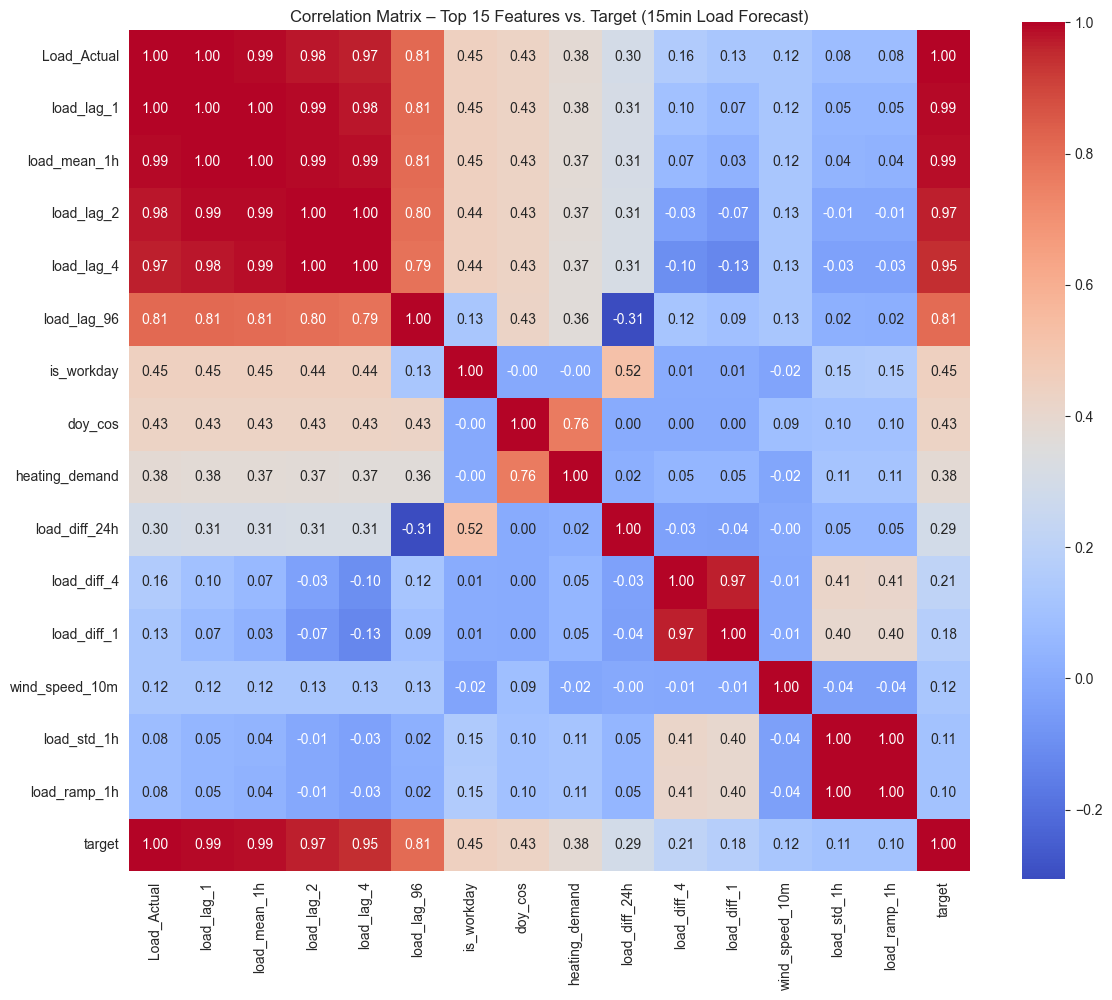

In [7]:
# Only numeric features
numeric_df = df.select_dtypes(include=["float64", "int64"])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Only correlations with the target variable
target_corr = corr_matrix["target"].drop("target").sort_values(ascending=False)

# Heatmap (Top 15)
top_features = target_corr.head(15).index.tolist() + ["target"]

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix.loc[top_features, top_features], annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix – Top 15 Features vs. Target (15min Load Forecast)")
plt.tight_layout()
plt.show()

✅ RMSE  : 59.42
✅ MAE   : 45.08
✅ MAPE  : 0.68%


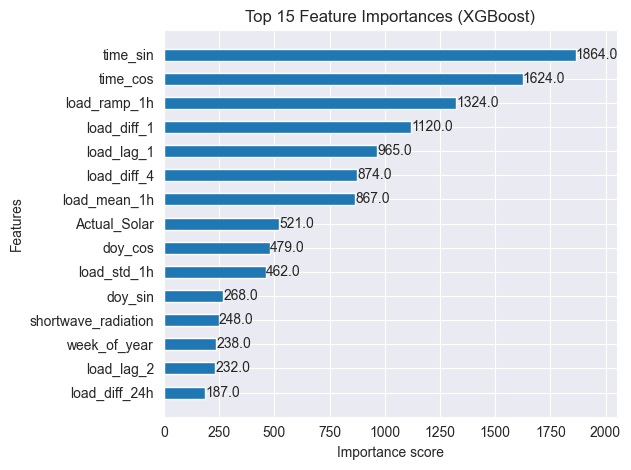

In [8]:
# Prepare Data
df["target"] = df["Load_Actual"].shift(-1)

df = df.dropna().reset_index(drop=True)

exclude = [col for col in ["DateTime", "Load_Actual", "target"] if col in df.columns]

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
features = [col for col in numeric_cols if col not in exclude]

# Split Data
split_index = int(len(df) * 0.8)
X_train = df.loc[:split_index, features]
y_train = df.loc[:split_index, "target"]
X_test  = df.loc[split_index+1:, features]
y_test  = df.loc[split_index+1:, "target"]

# Configurate Model
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae  = mean_absolute_error(y_test, y_pred)
mape = (np.abs((y_test - y_pred) / y_test).mean()) * 100

print(f"✅ RMSE  : {rmse:.2f}")
print(f"✅ MAE   : {mae:.2f}")
print(f"✅ MAPE  : {mape:.2f}%")

# Feature Importance
xgb.plot_importance(model, max_num_features=15, height=0.5)
plt.title("Top 15 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

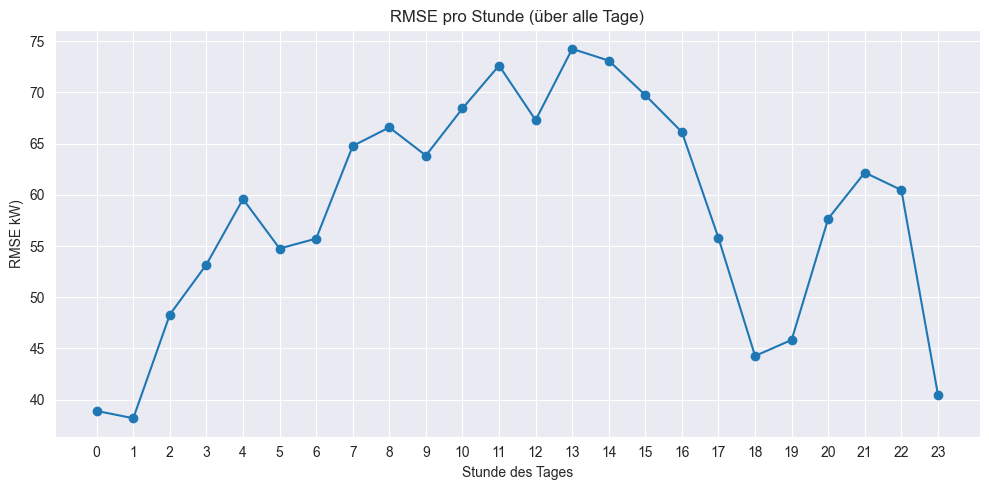

100%|===================| 46494/46619 [05:11<00:00]        

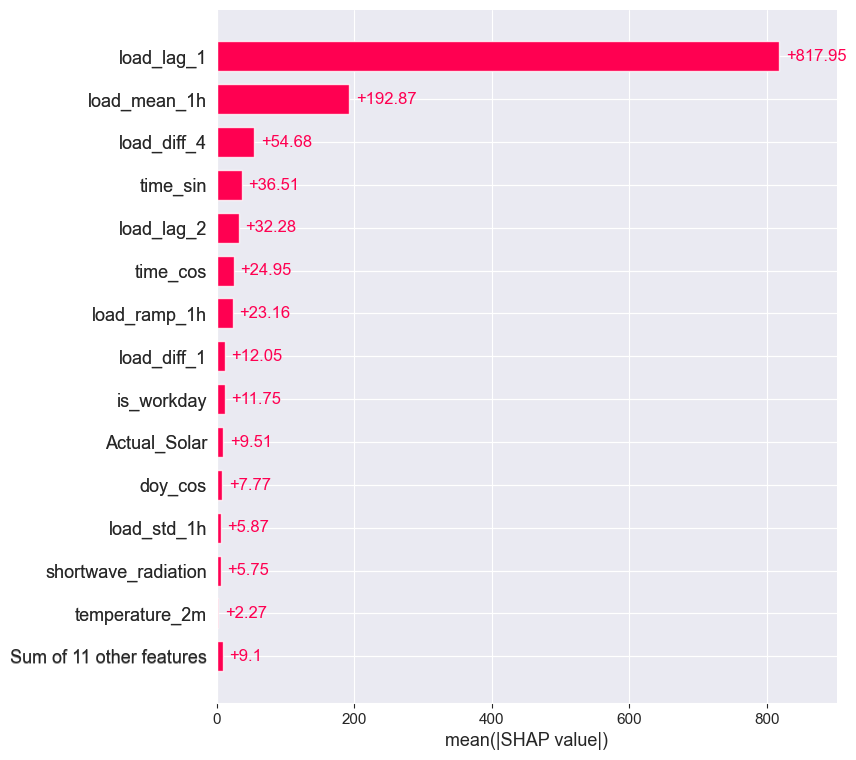

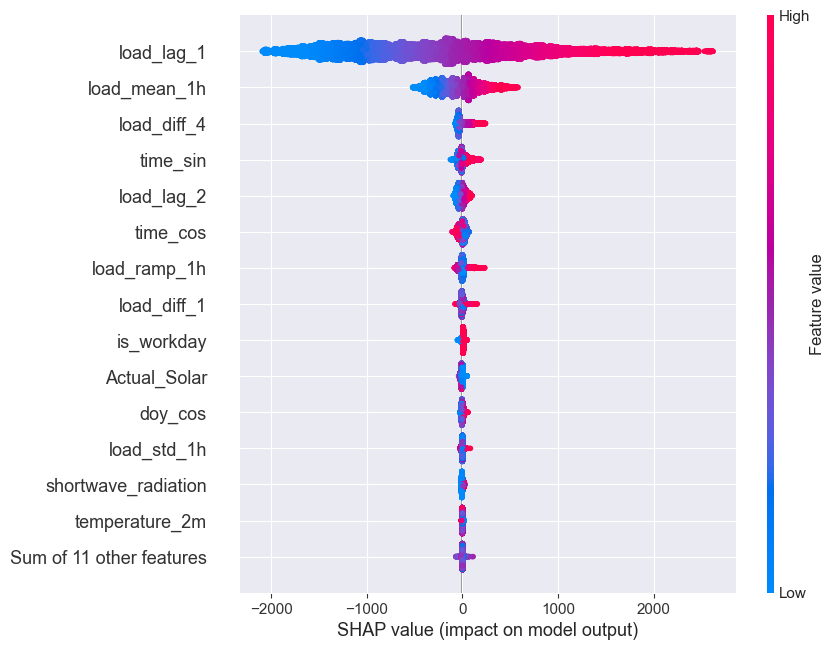

In [9]:
# Plot RMSE
df_test = df.loc[split_index+1:].copy()
df_test = df_test.iloc[:len(y_pred)].copy()
df_test["y_pred"] = y_pred
df_test["error_squared"] = (df_test["target"] - df_test["y_pred"]) ** 2

df_test["hour_of_day"] = df_test["DateTime"].dt.hour
rmse_by_hour = df_test.groupby("hour_of_day")["error_squared"].mean().apply(np.sqrt)

plt.figure(figsize=(10, 5))
plt.plot(rmse_by_hour.index, rmse_by_hour.values, marker="o")
plt.title("RMSE pro Stunde (über alle Tage)")
plt.xlabel("Stunde des Tages")
plt.ylabel("RMSE kW)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()# SHAP evaluator
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
shap.plots.bar(shap_values, max_display=15)
shap.plots.beeswarm(shap_values, max_display=15)

In [ ]:
# objective function
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.3, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": 42,
    } 

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    return rmse

# study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=500, show_progress_bar=True)

# 3. Beste Parameter anzeigen
print("\n✅ Beste Parameter:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")
print(f"\n🏆 Bestes RMSE (Testdaten): {study.best_value:.2f}")

# train best model
best_model = xgb.XGBRegressor(**study.best_params)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# evaluate
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae  = mean_absolute_error(y_test, y_pred)
mape = (np.abs((y_test - y_pred) / y_test).mean()) * 100

print(f"\n📊 Modellbewertung (Testdaten):")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}%")

# most important features
xgb.plot_importance(best_model, max_num_features=15, height=0.5)
plt.title("Top 15 Feature Importances (Optimiertes XGBoost)")
plt.tight_layout()
plt.show()



[I 2025-06-23 18:48:37,979] A new study created in memory with name: no-name-8be482b5-5550-4203-a123-38aaf4389893
Best trial: 0. Best value: 52.4262:   0%|          | 1/500 [00:02<17:42,  2.13s/it]

[I 2025-06-23 18:48:40,118] Trial 0 finished with value: 52.42617716849754 and parameters: {'n_estimators': 304, 'max_depth': 8, 'learning_rate': 0.06568796543252428, 'subsample': 0.41481089281894973, 'colsample_bytree': 0.4118954308064653, 'min_child_weight': 8}. Best is trial 0 with value: 52.42617716849754.


Best trial: 0. Best value: 52.4262:   0%|          | 2/500 [00:03<15:16,  1.84s/it]

[I 2025-06-23 18:48:41,757] Trial 1 finished with value: 62.51576678875046 and parameters: {'n_estimators': 598, 'max_depth': 3, 'learning_rate': 0.13536126496000045, 'subsample': 0.7823889827356825, 'colsample_bytree': 0.5656893499914128, 'min_child_weight': 6}. Best is trial 0 with value: 52.42617716849754.


Best trial: 0. Best value: 52.4262:   1%|          | 3/500 [00:06<18:43,  2.26s/it]

...

Best trial: 0. Best value: 52.4262:   1%|          | 5/500 [00:09<14:36,  1.77s/it]

[I 2025-06-23 18:48:47,523] Trial 4 finished with value: 53.52162770706348 and parameters: {'n_estimators': 246, 'max_depth': 7, 'learning_rate': 0.2448017922190061, 'subsample': 0.8478530121026631, 'colsample_bytree': 0.9529540297930845, 'min_child_weight': 4}. Best is trial 0 with value: 52.42617716849754.


Best trial: 0. Best value: 52.4262:   1%|          | 5/500 [00:10<17:44,  2.15s/it]


[W 2025-06-23 18:48:48,717] Trial 5 failed with parameters: {'n_estimators': 915, 'max_depth': 5, 'learning_rate': 0.2411907432848291, 'subsample': 0.8380767694583555, 'colsample_bytree': 0.44939695352375375, 'min_child_weight': 10} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\Julian Gaming\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Julian Gaming\AppData\Local\Temp\ipykernel_12764\4058742699.py", line 14, in objective
    model.fit(X_train, y_train)
  File "C:\Users\Julian Gaming\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "C:\Users\Julia

KeyboardInterrupt: 